## The PPG Wave Synthesizer Block Diagram

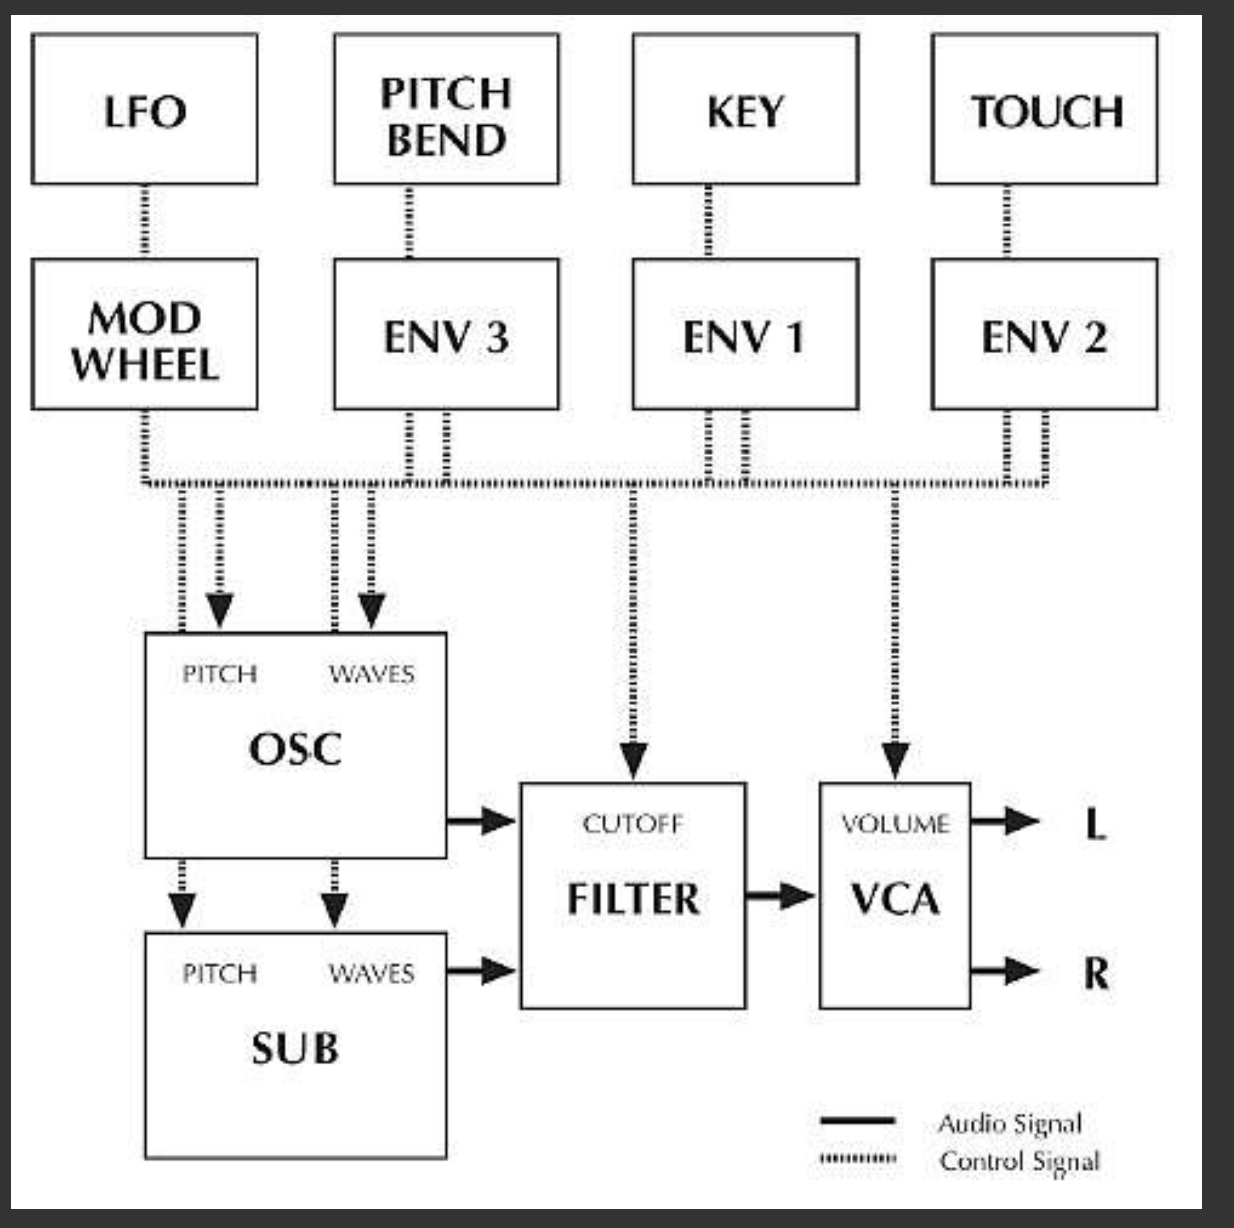

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from waveTableOscillator import voiceGenerator, phaseGenerator, waveTable, linearInterpolator
from scipy.io import wavfile

Implementing an ADSR and simple key control

In [5]:
def ADSR(attackTime, decayTime, sustainTime, releaseTime, samplerate):
    # An attack is a linear ramp up
    attack = np.linspace(0, 1, int(samplerate*attackTime))
    # An Decay is a linear ramp down
    decay = np.linspace(1, 0.5, int(samplerate*decayTime))
    # Sustain is a unit-step function
    sustain = np.linspace(0.5, 0.5, int(samplerate*sustainTime))
    # Release is another linear ramp down
    release = np.linspace(0.5, 0, int(samplerate*releaseTime))

    adsr = np.concatenate((attack, decay, sustain, release), axis=None)
    return adsr
    
def key_control(wave_type, table_size, frequency, attackTime, decayTime, sustainTime, releaseTime, samplerate=48000, duty_cycle=0.5):
    wave = voiceGenerator(table_size)
    adsr_env = ADSR(attackTime, decayTime, sustainTime, releaseTime, samplerate)
    duration = len(adsr_env)/samplerate
    audio = wave.waveform(wave_type, frequency, duration, duty_cycle)
    note = adsr_env * audio
    
    return note

## Simple Synthesis

In [7]:
# Generate some notes
if __name__ == "__main__":

    # Define sample rate and table size
    sample_rate = 48000
    table_size = 2048
    
    # Define frequencies for a C major scale (C4 to C5)
    c_major_scale = {
        'C4': 261.63,
        'D4': 293.66,
        'E4': 329.63,
        'F4': 349.23,
        'G4': 392.00,
        'A4': 440.00,
        'B4': 493.88,
        'C5': 523.25
    }
    
    # ADSR parameters for different note types
    short_note = (0.01, 0.1, 0.1, 0.2)  # Short staccato note
    medium_note = (0.05, 0.2, 0.4, 0.3)  # Medium length note
    long_note = (0.1, 0.3, 1.0, 0.5)     # Long sustained note
    
    # Create an empty array for our song
    song = np.array([])
    
    # Add notes to the song
    sequence = [
        # Note name, waveform, ADSR type
        ('C4', 'sine', medium_note),
        ('E4', 'triangle', medium_note),
        ('G4', 'square', medium_note),
        ('C5', 'saw', long_note),
        ('G4', 'square', short_note),
        ('E4', 'triangle', short_note),
        ('C4', 'sine', long_note)
    ]
    
    for note_name, wave_type, adsr_type in sequence:
        frequency = c_major_scale[note_name]
        attackTime, decayTime, sustainTime, releaseTime = adsr_type
        
        # Generate the note
        note_data = key_control(
            wave_type, 
            table_size, 
            frequency, 
            attackTime, 
            decayTime, 
            sustainTime, 
            releaseTime, 
            sample_rate
        )
        
        song = np.append(song, note_data)
    
    # Normalize to prevent clipping
    song = song / np.max(np.abs(song))
    
    # Convert to 16-bit audio
    song_int16 = (song * 32767).astype(np.int16)
    
    # Save to WAV file
    wavfile.write("wavetable_melody.wav", sample_rate, song_int16)

    
    # Create three notes with different waveforms
    c_note = key_control('sine', table_size, c_major_scale['C4'], 0.1, 0.1, 0.8, 0.5, sample_rate)
    e_note = key_control('triangle', table_size, c_major_scale['E4'], 0.1, 0.1, 0.8, 0.5, sample_rate)
    g_note = key_control('saw', table_size, c_major_scale['G4'], 0.1, 0.1, 0.8, 0.5, sample_rate)
    
    # Mix them together (ensure same length)
    min_length = min(len(c_note), len(e_note), len(g_note))
    chord = (c_note[:min_length] + e_note[:min_length] + g_note[:min_length]) / 3.0
    
    # Convert to 16-bit audio
    chord_int16 = (chord * 32767).astype(np.int16)
    
    # Save to WAV file
    wavfile.write("wavetable_chord.wav", sample_rate, chord_int16)

## Modulation

In [ ]:
def generate_lfo(lfo_type, lfo_freq, duration, sample_rate=48000):
# Create a voice generator for the LFO
    vg = voiceGenerator(table_size=1024)
    
    # Generate the LFO signal
    lfo_signal = vg.waveform(lfo_type, lfo_freq, duration)
    
    lfo_signal = (lfo_signal + 1) / 2
    
    return lfo_signal

## SNR Calculation

The SNR for a table lookup sine oscillator can be approximated as, where $N$ is the size of the table:

$$
\text{SNR} \approx 6.02 \cdot \log_2(N) + \text{constant}
$$

This can be calculated with the function below

In [21]:
def calculate_wavetable_snr(frequency, duration, table_size=1024, sample_rate=48000):
    
    # Generate wavetable signal
    wave_type = 'sine'
    vg = voiceGenerator(table_size)
    wavetable_signal = vg.waveform(wave_type, frequency, duration)
    
    # Generate ideal reference signal
    num_samples = len(wavetable_signal)
    time = np.arange(num_samples) / sample_rate
    reference_signal = np.sin(2 * np.pi * frequency * time)
    
    # Calculate noise as difference between wavetable and reference
    noise = wavetable_signal - reference_signal
    
    # Calculate SNR
    signal_power = np.mean(reference_signal**2)
    noise_power = np.mean(noise**2)
    
    if noise_power == 0:  # Avoid division by zero
        return float('inf')
    
    snr = 10 * np.log10(signal_power / noise_power)
    
    return snr

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [20]:
# Experiment with table_size and SNR
snr = calculate_wavetable_snr(440, 2, table_size=24, sample_rate=48000)